In [4]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit.transpiler.passes import BasisTranslator
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary as sel
from qiskit.converters import circuit_to_dag, dag_to_circuit

['cz', 'rz', 'sx', 'x', 'id']
['cz', 'rz', 'sx', 'x', 'id']
['cz', 'rz', 'sx', 'x', 'id']
['cz', 'rz', 'sx', 'x', 'id', 'reset', 'delay', 'measure']
Distance matrix:
 [[0, 1, 1, 2], [1, 0, 2, 1], [1, 2, 0, 3], [2, 1, 3, 0]]
Performing swap: (2, 0) to resolve dependency: g1
-----------------------------------------------------------

Performing swap: (2, 1) to resolve dependency: g1
-----------------------------------------------------------

Performing swap: (3, 2) to resolve dependency: g3
-----------------------------------------------------------

Performing swap: (3, 1) to resolve dependency: g3
-----------------------------------------------------------

Performing swap: (0, 3) to resolve dependency: g4
-----------------------------------------------------------

Performing swap: (0, 1) to resolve dependency: g4
-----------------------------------------------------------

Nodeid: o0
Nodeid: o9
Nodeid: o10
Nodeid: o1
Nodeid: o11
Nodeid: o2
Nodeid: o12
Nodeid: g0
Nodeid: o3
Nodeid: 

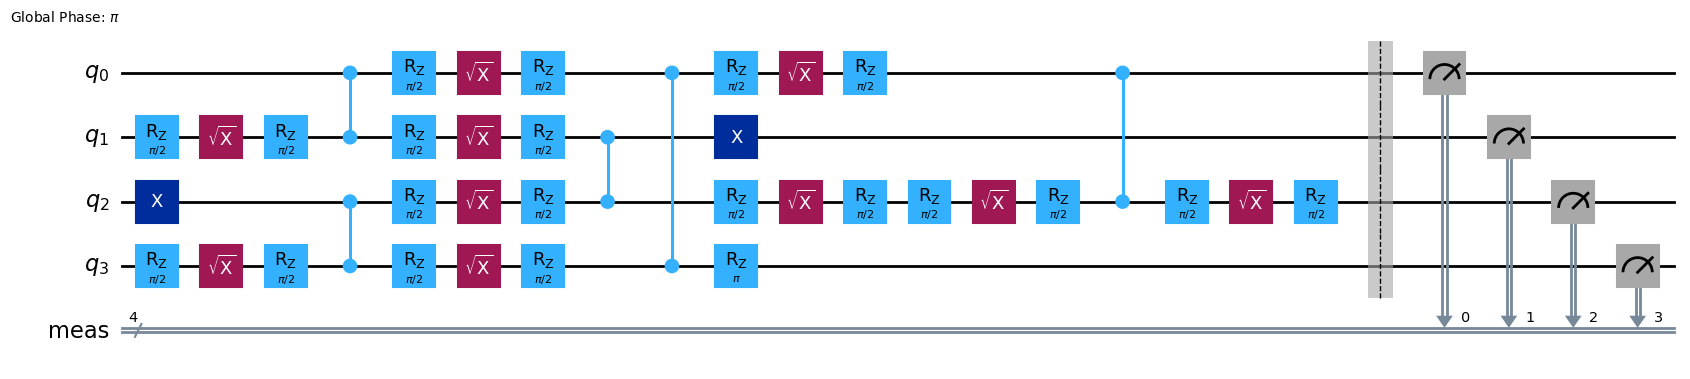

In [10]:
qc = QuantumCircuit(4)
qc.cx(0,1)
qc.x(2)
qc.cx(2,3)
qc.cx(1,2)
qc.x(1)
qc.cx(3,0)
qc.z(3)
qc.cx(0,2)

# qc.save_statevector()

qc.measure_all()

# 2D grid topology (3x3)
# Qubits arranged as:
#  0 - 1 - 2
#  |   |   |
#  3 - 4 - 5
#  |   |   |
#  6 - 7 - 8

complex_coupling = [
    # Horizontal edges
    [0, 1], [1, 2],
    [3, 4], [4, 5],
    [6, 7], [7, 8],
    # Vertical edges
    [0, 3], [3, 6],
    [1, 4], [4, 7],
    [2, 5], [5, 8],
]

target_gates = ["cz",  "rz", "sx", "x", "id"]
print(target_gates)
#----------------------------------------------------------------
translator = BasisTranslator(sel, target_basis=target_gates)
print(target_gates)
dag = circuit_to_dag(qc)
translated_dag = translator.run(dag)
translated_circuit = dag_to_circuit(translated_dag)
qc = translated_circuit
print(target_gates)
#----------------------------------------------------------------

backend_complex = GenericBackendV2(
    num_qubits=9,
    basis_gates=target_gates,
    coupling_map=complex_coupling,
    seed=123
)
print(target_gates)
sim = AerSimulator()

qc_layout, mapping = Layout.run_layout(qc, backend_complex)

qc.draw("mpl")

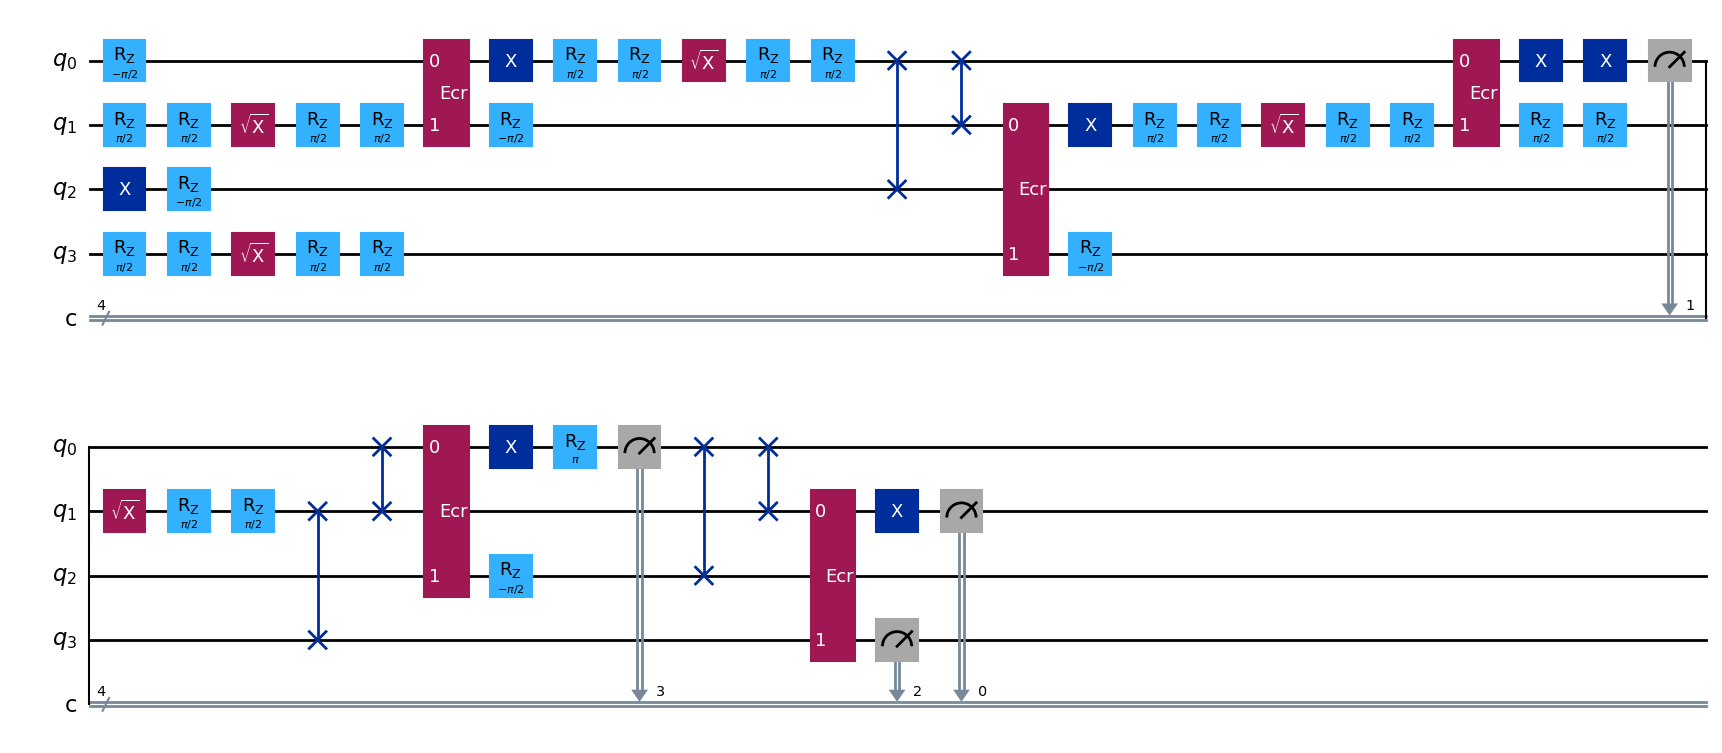

In [17]:
# qc_layout.save_statevector()
qc_layout.draw("mpl")

In [4]:
result = sim.run(qc).result()
sv_original = result.get_statevector()
print("Original statevector:", sv_original)

Original statevector: Statevector([ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
              0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j, -1.+0.j, -0.+0.j, -0.+0.j,
             -0.+0.j, -0.+0.j],
            dims=(2, 2, 2, 2))


In [5]:
from qiskit.quantum_info import Statevector
sv = Statevector(sv_original)
sv.draw('latex')

<IPython.core.display.Latex object>

In [7]:
result_layout = sim.run(qc_layout).result()
sv_layout = result_layout.get_statevector()

sv_layout = Statevector(sv_layout)
sv_layout.draw('latex')

<IPython.core.display.Latex object>

In [19]:
result = sim.run(qc_layout).result()
counts = result.get_counts()
print("Counts after layout:", counts)

Counts after layout: {'1011': 1024}


In [20]:
result = sim.run(qc).result()
counts = result.get_counts()
print("Counts before layout:", counts)

Counts before layout: {'1011': 1024}


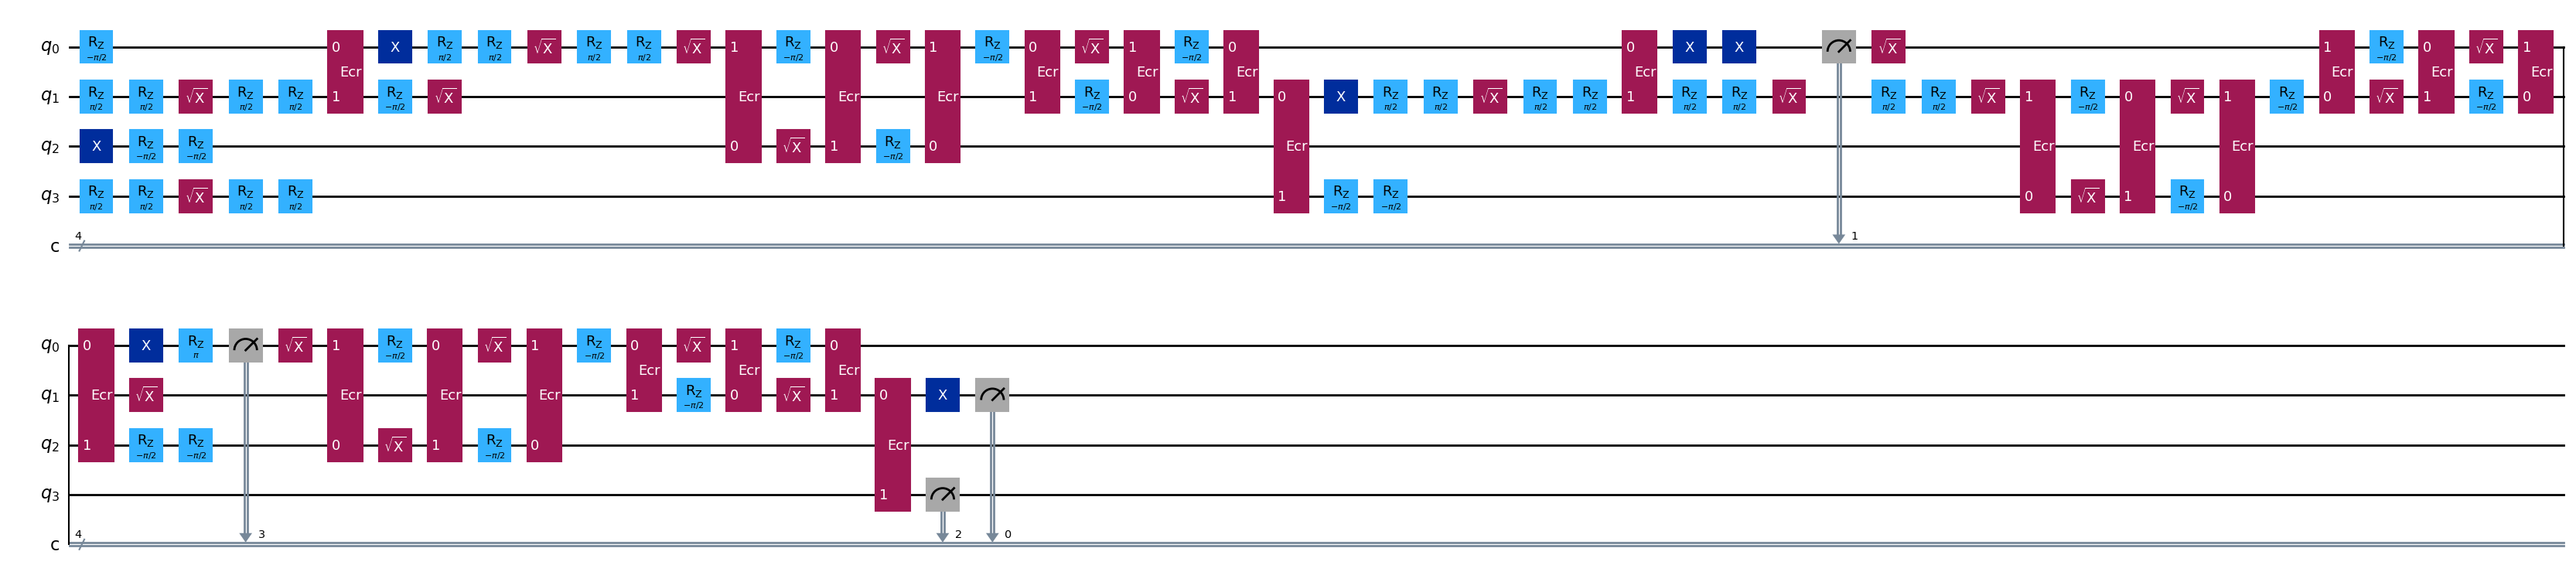

In [18]:
translator = BasisTranslator(sel, target_basis=target_gates)

dag = circuit_to_dag(qc_layout)
translated_dag = translator.run(dag)
translated_circuit = dag_to_circuit(translated_dag)
translated_circuit.draw("mpl", fold=50)

['cz', 'rz', 'sx', 'x', 'id']
Checking if target_basis frozenset({'rz', 'id', 'sx', 'cz', 'x'}) is subset of eagle basis frozenset({'sx', 'id', 'rz', 'ecr', 'x'})...
Checking if target_basis frozenset({'rz', 'id', 'sx', 'cz', 'x'}) is subset of heron basis frozenset({'sx', 'cz', 'id', 'rz', 'x'})...
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron' equivalences as fallback.
[BasisTranslator] Warning: custom_basis provided without custom_equivalences — using built-in ECR equivalence table as fallback.


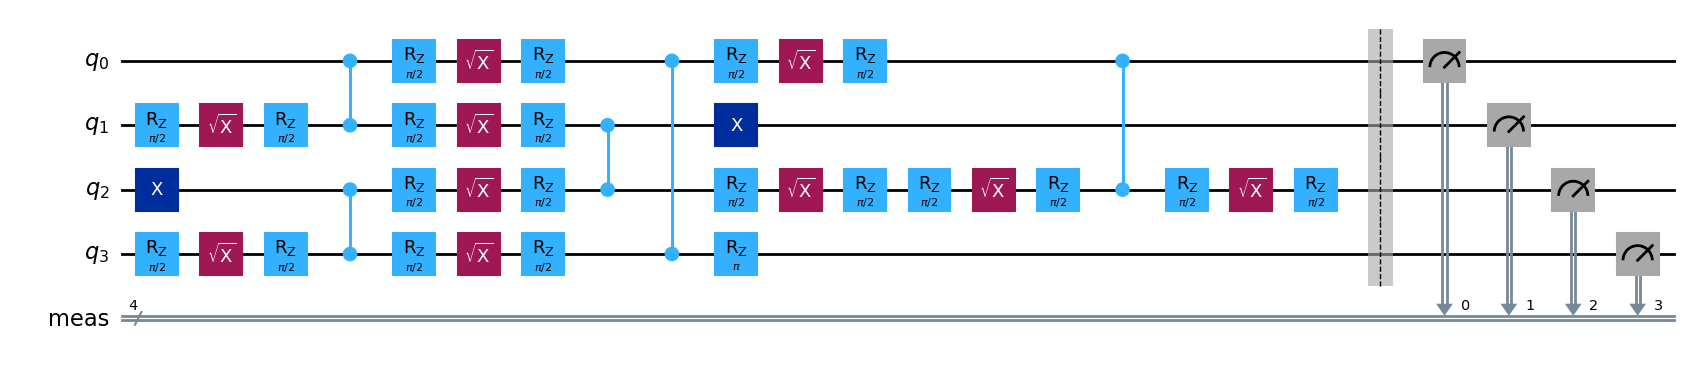

In [8]:
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
target_gates = ["cz",  "rz", "sx", "x", "id"]
print(target_gates)

translated_circuit_2 = translate_circuit(qc, basis=target_gates)

translated_circuit_2.draw("mpl", fold=50)